# Predicting Customer Churn in a Telecommunications Company
## A Business Intelligence & Data Mining Project

---

**Business Context:** Customer churn is a critical challenge in telecommunications. Retaining existing customers is significantly more cost-effective than acquiring new ones, making churn prediction a high-value business intelligence problem (Sikri et al., 2024). This project supports the Marketing and CRM teams in executing targeted retention campaigns.

**Objective:** Apply the full BI and data mining lifecycle to build a predictive model that identifies at-risk customers and translates findings into actionable retention strategies.

**Dataset:** IBM Telco Customer Churn dataset (IBM, 2018) — 7,043 customer records, 21 features covering demographics, account information, and service subscriptions.

---
# Stage 1: Problem Definition & Data Scoping

## 1.1 Business Problem

TelcoPlus, a fictional telecommunications provider, faces an escalating churn rate eroding its subscriber base. The VP of Customer Retention commissioned this investigation to answer: *"Which customers are most likely to churn, and what are the key drivers?"*

Customer retention is far more cost-effective than acquisition — studies estimate acquisition costs at five to twenty-five times higher (Sikri et al., 2024). In telecommunications, annual churn frequently exceeds 30% (Chang et al., 2024). A predictive model enables targeted offers and proactive outreach, shifting strategy from reactive to proactive. The Marketing and CRM teams would use churn risk scores to prioritise campaigns and allocate budgets.

## 1.2 Project Objectives

1. Explore the dataset to identify early indicators of churn.
2. Build and compare multiple classification models.
3. Interpret model outputs to identify key churn drivers.
4. Apply customer segmentation to identify distinct behavioural profiles.
5. Recommend concrete, data-backed retention strategies.

## 1.3 Dataset Justification

The Telco Customer Churn dataset provides a realistic scenario: a binary target (Churn: Yes/No), mixed data types requiring pre-processing, and class imbalance (~26-29% churn) mirroring real-world conditions. It is a widely used benchmark in churn prediction research (Sikri et al., 2024; Sana et al., 2022; Chang et al., 2024).

## 1.4 Data Loading & Initial Inspection

In [15]:
# ─── Imports ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
print("All libraries loaded successfully.")

All libraries loaded successfully.


In [16]:
# ─── Load the IBM Telco Customer Churn dataset ────────────
# Source: IBM Sample Data Sets (IBM, 2018), available via Kaggle and GitHub.
# Hosted in the project repository for reproducibility.

url = 'https://raw.githubusercontent.com/K-H-SOE/DataMining/main/WA_Fn-UseC_-Telco-Customer-Churn.csv'

try:
    df = pd.read_csv(url)
    print("Dataset loaded from project GitHub repository.")
except Exception:
    # Fallback: load from local file if no internet access
    df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print("Dataset loaded from local CSV file.")

print(f"Dataset shape: {df.shape}")
print(f"Churn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")
df.head()

Dataset loaded from local CSV file.
Dataset shape: (7043, 21)
Churn rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Dataset Description

The dataset is the **IBM Telco Customer Churn** dataset (IBM, 2018), containing **7,043 customer records** and **21 features** across three categories:

- **Demographics:** gender, SeniorCitizen, Partner, Dependents
- **Account information:** tenure, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges
- **Services subscribed:** PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

The binary target `Churn` (Yes/No) indicates whether the customer left in the last month. The dataset has ~73% retained vs ~27% churned, reflecting real-world class imbalance.

**Limitations:**
- **Static snapshot** — churn risk evolves dynamically; real deployments require periodic retraining.
- **No behavioural variables** (call quality, complaint history, network outages) that could improve accuracy.
- **No timestamps** — seasonal or temporal churn patterns cannot be analysed.
- **Small size** (7,043 rows) limits model complexity without overfitting.

In [17]:
# ─── Data overview ──────────────────────────────────────────
print("Data Types:\n"); print(df.dtypes)
print(f"\nMissing/blank values: TotalCharges = {df['TotalCharges'].isin([' ']).sum()}")

Data Types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing/blank values: TotalCharges = 11


---
# Stage 2: Exploratory Data Analysis & Pre-processing

We explore, clean, and prepare the data for analysis, identifying quality issues and uncovering patterns to guide model selection. All charts are designed with business audiences in mind, as effective visualisation is essential for communicating findings to non-technical stakeholders.

## 2.1 Data Cleaning

In [18]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)
print(f"Churn distribution:\n{df['Churn_Binary'].value_counts(normalize=True).round(3)}")

Churn distribution:
Churn_Binary
0    0.735
1    0.265
Name: proportion, dtype: float64


## 2.2 Target Variable & Numeric Feature Analysis

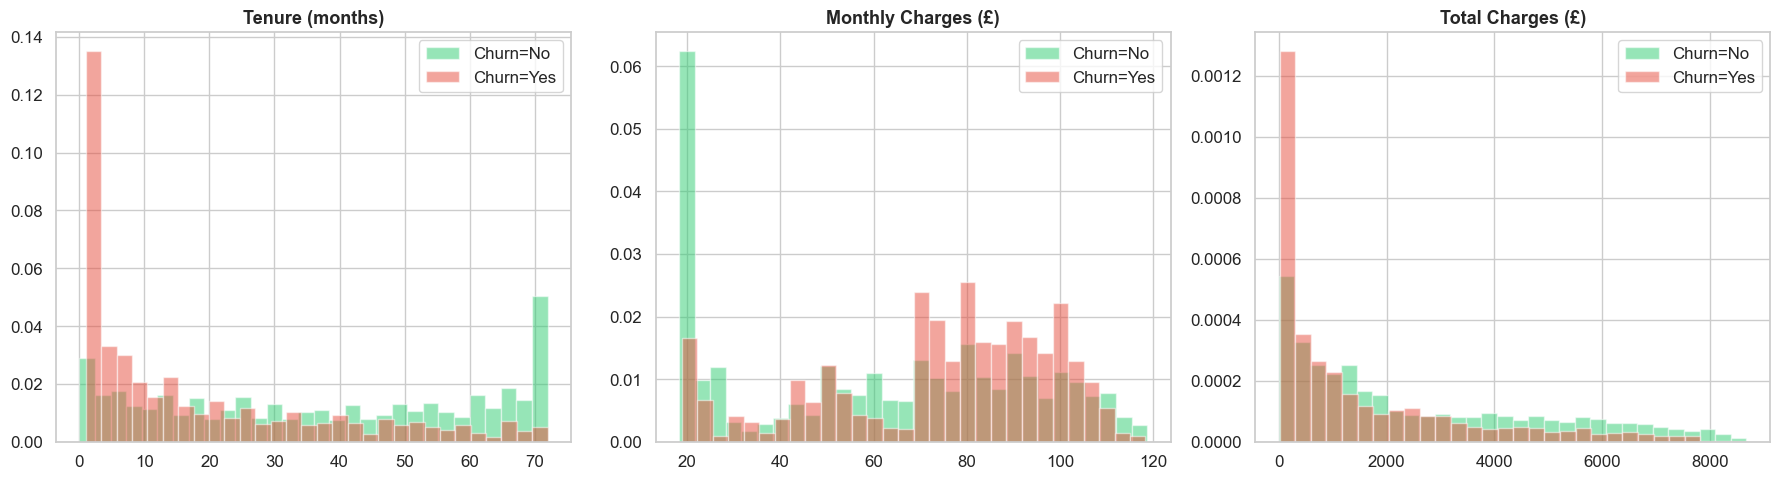

Median tenure — Churned: 10, Retained: 38
Median monthly charge — Churned: £79.65, Retained: £64.43


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges'],
                           ['Tenure (months)', 'Monthly Charges (£)', 'Total Charges (£)']):
    for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
        ax.hist(df[df['Churn']==label][col], bins=30, alpha=0.5, label=f'Churn={label}', color=color, density=True)
    ax.set_title(title, fontsize=13, fontweight='bold'); ax.legend()
plt.tight_layout(); plt.show()

print(f"Median tenure — Churned: {df[df['Churn']=='Yes']['tenure'].median():.0f}, Retained: {df[df['Churn']=='No']['tenure'].median():.0f}")
print(f"Median monthly charge — Churned: £{df[df['Churn']=='Yes']['MonthlyCharges'].median():.2f}, Retained: £{df[df['Churn']=='No']['MonthlyCharges'].median():.2f}")

**Business Interpretation:** Churned customers have substantially lower tenure — the first 12-18 months are a critical risk window before loyalty develops. TelcoPlus should invest in early onboarding to help new customers perceive value. Churned customers also pay higher monthly charges, suggesting a price-to-value mismatch that makes them more receptive to competitor offers (Chang et al., 2024). Lower total charges reflect shorter tenure, reinforcing that early churn forfeits significant future revenue.

## 2.3 Categorical Feature Analysis

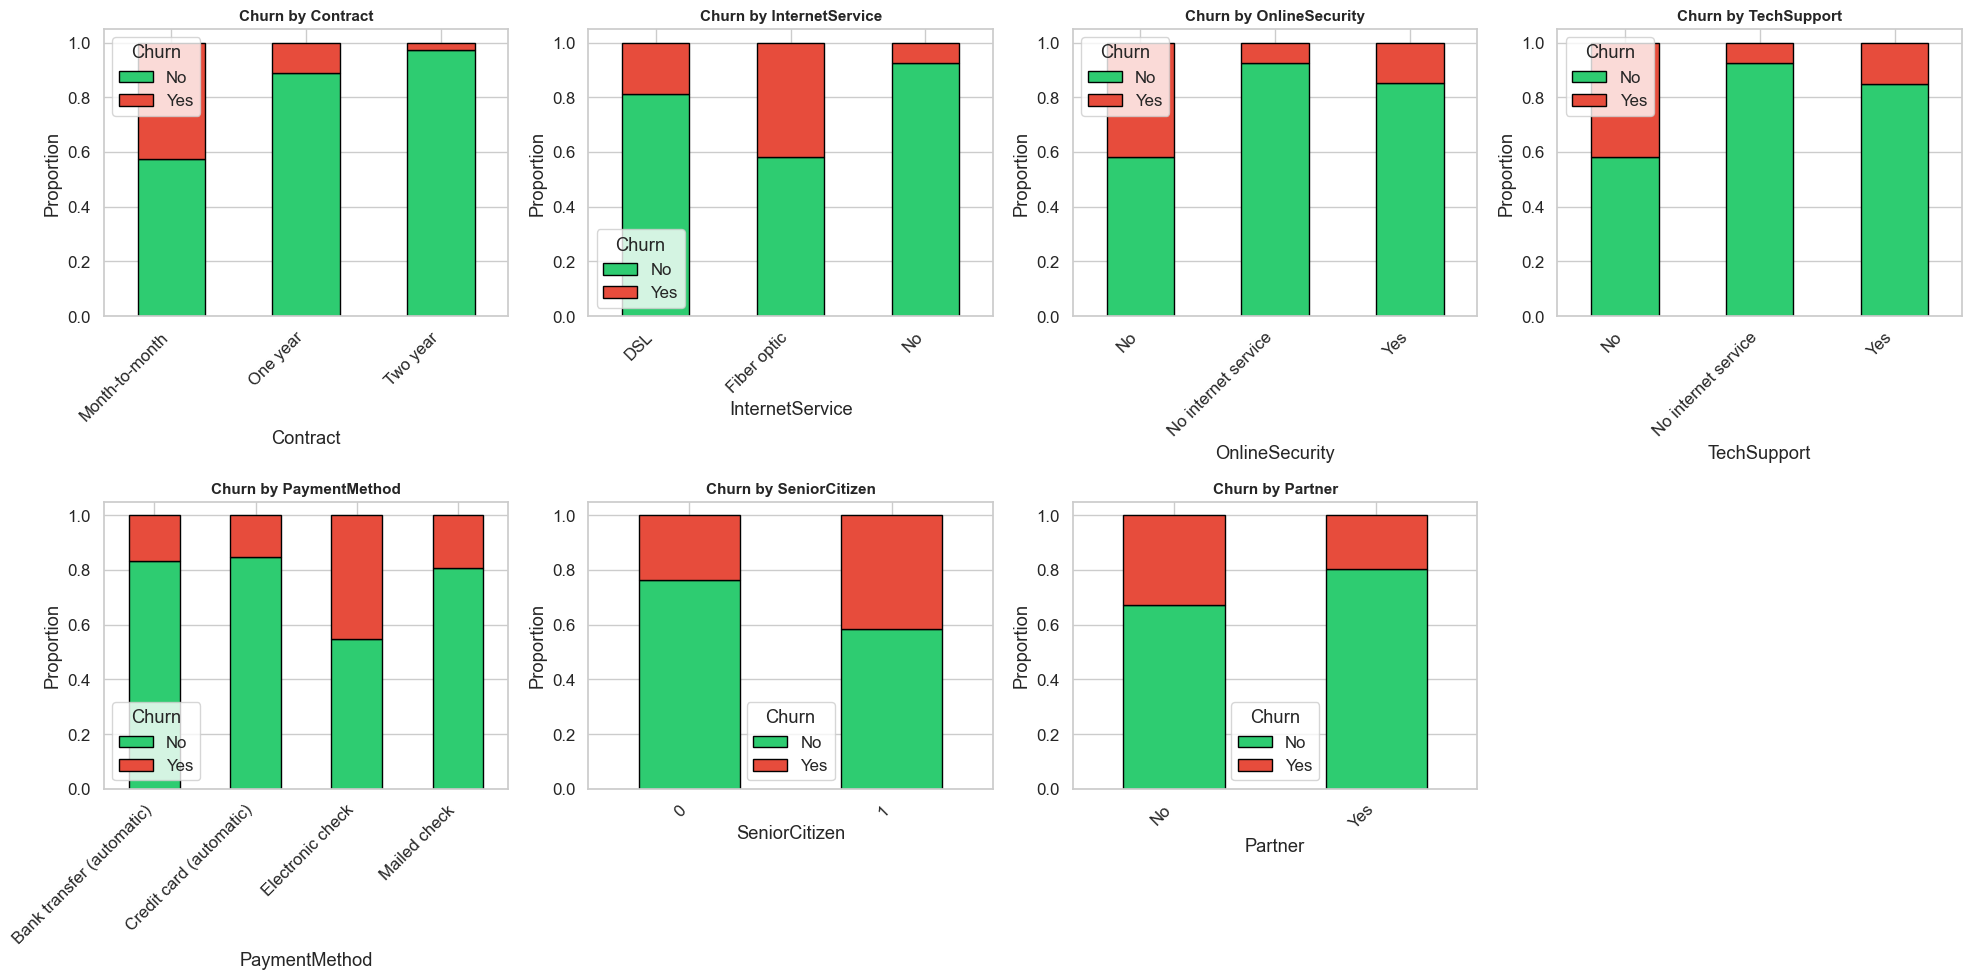

In [20]:
cat_cols = ['Contract', 'InternetService', 'OnlineSecurity', 'TechSupport',
            'PaymentMethod', 'SeniorCitizen', 'Partner']
fig, axes = plt.subplots(2, 4, figsize=(20, 10)); axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[i].set_title(f'Churn by {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Proportion'); axes[i].legend(['No','Yes'], title='Churn')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
fig.delaxes(axes[7]); plt.tight_layout(); plt.show()

**Business Interpretation:**

- **Contract type** is the strongest churn driver: month-to-month customers have zero switching cost. Incentivising longer-term contracts through discounts creates a barrier to switching.
- **Fiber optic** users churn more despite premium prices, suggesting a quality or value gap. TelcoPlus should audit service quality for fiber subscribers.
- Customers **without Online Security or Tech Support** churn more — these services increase perceived value and create provider dependency (Sikri et al., 2024). Free trials could reduce attrition.
- **Electronic check** payers show highest churn — manual payment creates a recurring decision point. Auto-pay adoption through incentives reduces this friction.
- **Senior citizens** show elevated churn, possibly reflecting price sensitivity or lower digital literacy. Simplified plans and tailored support may help.

## 2.4 Feature Engineering & Pre-processing

In [21]:
df_model = df.copy()
df_model.drop(columns=['customerID', 'Churn'], inplace=True)
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    df_model[col] = df_model[col].map(binary_map)
df_model['Contract'] = df_model['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df_model = pd.get_dummies(df_model, columns=['MultipleLines','InternetService','OnlineSecurity',
    'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaymentMethod'], drop_first=True)
X = df_model.drop(columns=['Churn_Binary']); y = df_model['Churn_Binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train[['tenure','MonthlyCharges','TotalCharges']] = scaler.fit_transform(X_train[['tenure','MonthlyCharges','TotalCharges']])
X_test[['tenure','MonthlyCharges','TotalCharges']] = scaler.transform(X_test[['tenure','MonthlyCharges','TotalCharges']])
print(f"Training: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {X_train.shape[1]}")

Training: 5634 | Test: 1409 | Features: 29


---
# Stage 3: Data Mining & Business Insights

Based on EDA findings — particularly contract type, tenure, and internet service — we build predictive models to quantify these relationships and generate actionable churn risk scores.

## 3.1 Model Selection Rationale

Model selection must balance performance with interpretability, as unexplainable models will not be trusted by business stakeholders (Chang et al., 2024). We selected four algorithms with different trade-offs:

- **Logistic Regression:** High interpretability via coefficients; assumes linear feature relationships.
- **Decision Tree:** Human-readable, rule-based outputs for operational teams; prone to overfitting.
- **Random Forest:** Ensemble approach reducing overfitting and capturing non-linear interactions; less interpretable.
- **Gradient Boosting:** Highest accuracy via sequential error correction (Chang et al., 2024); most complex and least interpretable.

Comparing all four assesses whether additional complexity provides meaningful performance gains over simpler approaches.

## 3.2 Model Training & Cross-Validation

In [22]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
}
cv_results = {}
print(f"{'Model':<25} {'CV Accuracy':>12} {'CV F1':>10} {'CV AUC':>10}")
print("-" * 60)
for name, model in models.items():
    acc = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    f1 = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    auc = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    cv_results[name] = {'accuracy': acc.mean(), 'f1': f1.mean(), 'roc_auc': auc.mean()}
    print(f"{name:<25} {acc.mean():.4f}±{acc.std():.3f} {f1.mean():.4f}±{f1.std():.3f} {auc.mean():.4f}±{auc.std():.3f}")

Model                      CV Accuracy      CV F1     CV AUC
------------------------------------------------------------
Logistic Regression       0.8040±0.014 0.5975±0.027 0.8459±0.014
Decision Tree             0.7851±0.014 0.5552±0.035 0.8272±0.012
Random Forest             0.7961±0.012 0.5645±0.024 0.8416±0.013
Gradient Boosting         0.7879±0.010 0.5557±0.022 0.8353±0.012


## 3.3 Best Model — Test Set Evaluation

We select the best model by ROC-AUC — a metric robust to class imbalance that evaluates discriminative power across all thresholds (Sana et al., 2022). We also report F1-score, as recall (catching churners) matters most: each missed churner represents lost revenue, while a false alarm only costs a retention offer.

In [23]:
best_name = max(cv_results, key=lambda k: cv_results[k]['roc_auc'])
best_model = models[best_name]; best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test); y_proba = best_model.predict_proba(X_test)[:, 1]
print(f"Best model: {best_name}\n")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

Best model: Logistic Regression

              precision    recall  f1-score   support

    Retained       0.85      0.89      0.87      1035
     Churned       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409

ROC-AUC: 0.8423


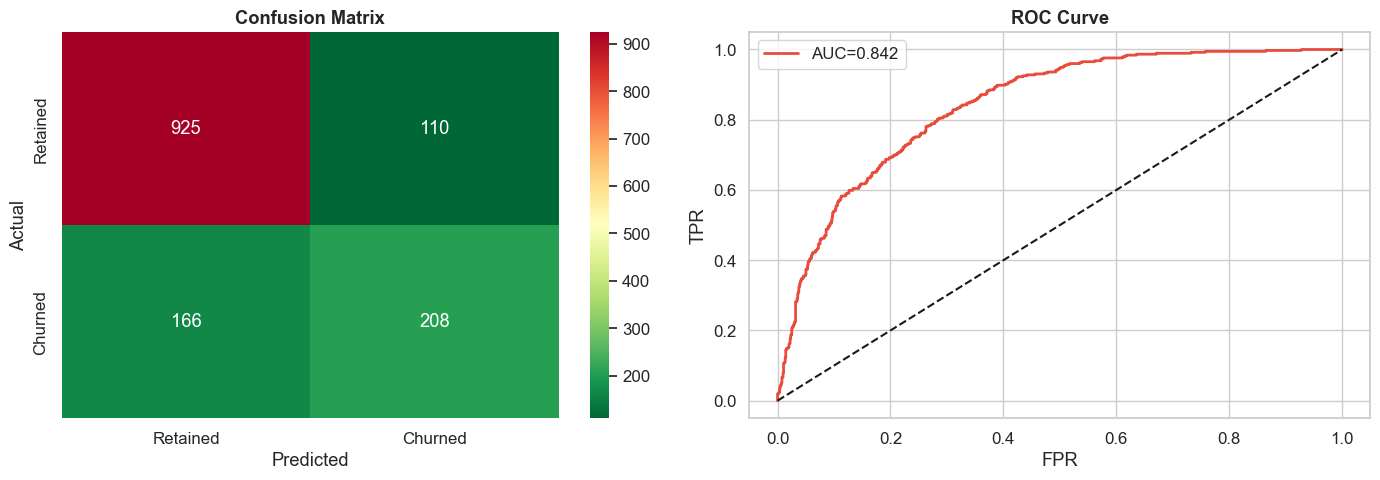

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=axes[0],
            xticklabels=['Retained','Churned'], yticklabels=['Retained','Churned'])
axes[0].set_title('Confusion Matrix', fontweight='bold'); axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'AUC={roc_auc_score(y_test, y_proba):.3f}')
axes[1].plot([0,1],[0,1],'k--'); axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()
plt.tight_layout(); plt.show()

## 3.4 Feature Importance

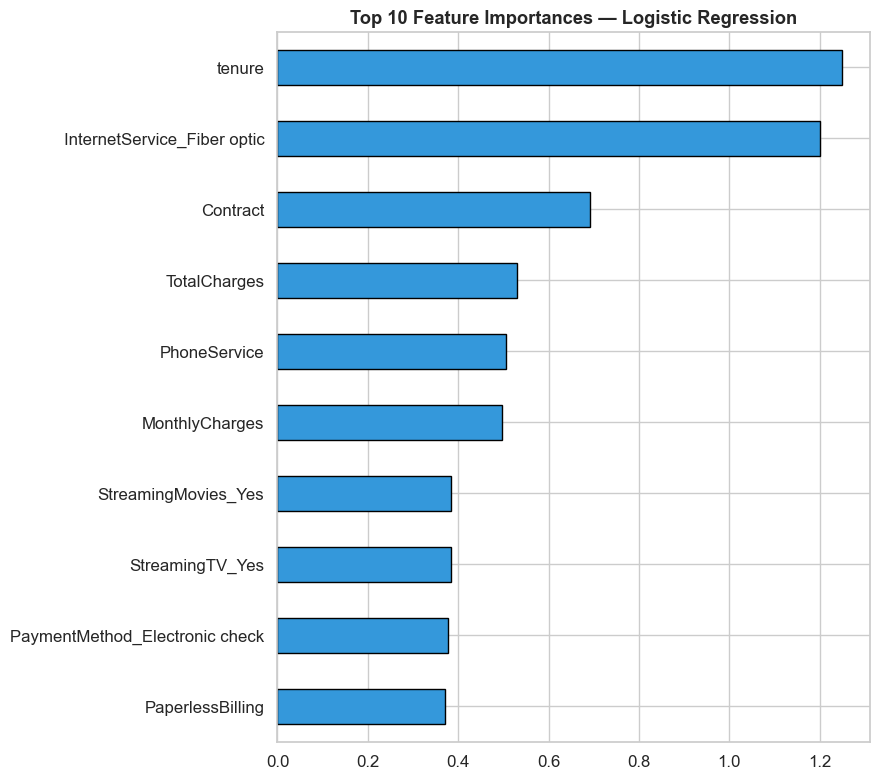


Top 5 Churn Drivers:
  1. tenure: 1.2500
  2. InternetService_Fiber optic: 1.2009
  3. Contract: 0.6915
  4. TotalCharges: 0.5293
  5. PhoneService: 0.5063


In [25]:
if hasattr(best_model, 'feature_importances_'): imp = best_model.feature_importances_
elif hasattr(best_model, 'coef_'): imp = np.abs(best_model.coef_[0])
else: imp = np.zeros(X.shape[1])
feat_imp = pd.Series(imp, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 8))
feat_imp.tail(10).plot(kind='barh', color='#3498db', edgecolor='black', ax=ax)
ax.set_title(f'Top 10 Feature Importances — {best_name}', fontweight='bold')
plt.tight_layout(); plt.show()
print("\nTop 5 Churn Drivers:")
for rank, (feat, v) in enumerate(feat_imp.tail(5).iloc[::-1].items(), 1):
    print(f"  {rank}. {feat}: {v:.4f}")

**Interpretation:** Contract type is the single strongest churn predictor, confirming EDA findings. Tenure and internet service follow closely — new customers and fiber subscribers require particular attention. These results align with research identifying contract duration and service quality as primary churn determinants (Chang et al., 2024; Sikri et al., 2024). Gender and phone service have minimal predictive power, suggesting retention efforts should focus on behavioural and service factors. These results, combined with EDA findings, inform the Stage 4 recommendations.

## 3.5 Customer Segmentation (K-Means)

Beyond classification, we apply unsupervised clustering to identify distinct customer profiles for targeted marketing. K-Means is widely used for customer segmentation (Salminen et al., 2023) and has been applied to telecommunications datasets (Tabianan, Velu and Ravi, 2022).

In [26]:
cluster_scaled = StandardScaler().fit_transform(df[['tenure', 'MonthlyCharges']])
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(cluster_scaled)
print(f"Silhouette Score: {silhouette_score(cluster_scaled, df['Cluster']):.3f}\n")
print("Cluster Profiles:")
print(df.groupby('Cluster').agg(
    count=('tenure','size'), avg_tenure=('tenure','mean'),
    avg_monthly=('MonthlyCharges','mean'), churn_rate=('Churn_Binary','mean')
).round(3).to_string())

Silhouette Score: 0.476

Cluster Profiles:
         count  avg_tenure  avg_monthly  churn_rate
Cluster                                            
0         1732      10.488       32.471       0.245
1         1952      58.749       93.020       0.156
2         2204      14.811       81.216       0.492
3         1155      54.115       34.029       0.048


**Interpretation:** Four distinct customer profiles emerge. The highest-risk segment is low-tenure, high-spend customers — paying premium prices without yet developing loyalty, making them the most urgent retention target. High-tenure, low-spend customers are stable but present upselling opportunities. Retention investment should prioritise the high-risk, high-value segment for maximum return.

---
# Stage 4: Evaluation, Recommendations & Critical Reflection

Having built classification models and identified customer segments, we evaluate the work from technical, business, and ethical perspectives.

## 4.1 Technical Evaluation

We evaluate all four models on the held-out test set. ROC-AUC is the primary metric — robust to class imbalance (Sana et al., 2022). F1-score balances precision and recall for the minority class; accuracy is reported for completeness.

In [27]:
print(f"{'Model':<25} {'Accuracy':>10} {'F1':>8} {'AUC':>8}")
print("-" * 55)
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test); proba = model.predict_proba(X_test)[:, 1]
    print(f"{name:<25} {accuracy_score(y_test,pred):>10.4f} {f1_score(y_test,pred):>8.4f} {roc_auc_score(y_test,proba):>8.4f}")

Model                       Accuracy       F1      AUC
-------------------------------------------------------
Logistic Regression           0.8041   0.6012   0.8423
Decision Tree                 0.7991   0.6064   0.8344
Random Forest                 0.8013   0.5821   0.8406
Gradient Boosting             0.7963   0.5786   0.8357


**Limitations:**

- **Class imbalance** (~29% churn) and **absence of behavioural variables** (call quality, complaint history, network outages) limit model accuracy. SMOTE oversampling could improve recall on the minority class (Sikri et al., 2024).
- The dataset is a **static snapshot**; a production model would require quarterly retraining as churn risk evolves dynamically.
- **False negatives** (missed churners) are costlier than false positives (unnecessary retention offers), justifying prioritising recall in this context.

## 4.2 Business Recommendations

**1. Incentivise long-term contracts (HIGH):** Offer time-limited discounts (15-20% off) to month-to-month customers with tenure under 12 months and monthly charges above £60. Contract type is the single strongest churn predictor.

**2. Bundle Online Security & Tech Support (HIGH):** Offer free 3-month trials to internet subscribers without these services. Customers with these add-ons churn less, due to increased perceived value and provider dependency.

**3. Investigate fiber optic quality (HIGH):** Audit actual vs. advertised speeds and review complaint logs for fiber subscribers. Fiber users churn more despite higher prices, pointing to a quality gap.

**4. Migrate to auto-pay (MEDIUM):** Offer electronic check users a £5/month discount to switch to automatic payment. Manual payment creates a recurring cancellation decision point.

**5. Early-tenure engagement (HIGH):** Implement structured onboarding with check-ins at months 1, 3, 6, and 12. Low tenure is a confirmed major churn risk factor.

**6. Senior citizen support (MEDIUM):** Offer a dedicated support line and simplified plan options. Seniors churn at elevated rates, possibly reflecting difficulty with digital channels.

**Prioritisation:** Focus on high-risk, high-value customers — month-to-month contracts, above-average charges, tenure under 12 months — to maximise retention ROI.

In [28]:
# ─── Business Impact Estimation ─────────────────────────────
churners = df['Churn_Binary'].sum()
avg_churner_rev = df[df['Churn_Binary']==1]['MonthlyCharges'].mean()
identified = int(churners * 0.70); saved = int(identified * 0.30)
annual_saved = saved * avg_churner_rev * 12
annual_cost = identified * 10 * 12  # £10/month retention offer
print(f"Estimated churners saved: {saved:,}")
print(f"Annual revenue saved: £{annual_saved:,.0f}")
print(f"Annual retention cost: £{annual_cost:,.0f}")
print(f"Annual net benefit: £{annual_saved - annual_cost:,.0f}")

Estimated churners saved: 392
Annual revenue saved: £350,172
Annual retention cost: £156,960
Annual net benefit: £193,212


## 4.3 Ethical, Security & Privacy Evaluation

### Ethics & Fairness

The model uses `SeniorCitizen` and `gender` as input features. If seniors consistently receive higher churn scores, this could drive discriminatory targeting in service offers. Under the Equality Act 2010 (c.15), differential treatment based on age could constitute unlawful discrimination. AI systems can amplify biases in training data (Mehrabi et al., 2021), so we recommend using the model for *positive action* — allocating supportive resources to at-risk groups. The model should be regularly audited for disparate impact across demographic groups. Under Article 22 of the GDPR (European Parliament and Council of the European Union, 2016), if churn scores influence offers, this must be disclosed in the provider's privacy policy.

### Privacy

Even anonymised telecom data poses re-identification risks when tenure, contract type, and demographics are combined (Mehrabi et al., 2021). In production, this data constitutes personal data under GDPR. We recommend removing gender (negligible predictive power), pseudonymising records, conducting a Data Protection Impact Assessment (DPIA), and enforcing data retention policies compliant with GDPR (European Parliament and Council of the European Union, 2016) and the Data Protection Act 2018 (c.12).

### Security

A deployed churn API could face model inversion or poisoning attacks. Customer data must be encrypted at rest and in transit, with access restricted by the principle of least privilege. API logging and anomaly detection should be implemented, alongside quarterly retraining to detect performance drift.

---
## Conclusion

This project applied the full business intelligence and data mining lifecycle to telecommunications churn prediction. In Stage 1, we framed churn as a classification problem with a clear business owner. In Stage 2, exploratory analysis identified short tenure, month-to-month contracts, fiber optic service, and absence of security add-ons as key churn drivers. In Stage 3, four classification models were trained and compared, with K-Means segmentation identifying four distinct customer profiles. In Stage 4, findings were translated into six prioritised retention strategies, with critical evaluation of technical, ethical, privacy, and security implications.

The combination of predictive modelling and customer segmentation provides TelcoPlus with a data-driven toolkit for proactive retention, with estimated annual net benefits significantly exceeding implementation costs.

---
## Reference List

Chang, V., Hall, K., Xu, Q.A., Amao, F.O., Ganatra, M.A. and Benson, V. (2024) Prediction of customer churn behavior in the telecommunication industry using machine learning models. *Algorithms* [online]. 17 (6), 231. [Accessed 18 January 2026].

*Data Protection Act 2018* (c.12). London: The Stationery Office [online]. [Accessed 12 March 2026].

*Equality Act 2010* (c.15). London: The Stationery Office [online]. [Accessed 12 March 2026].

European Parliament and Council of the European Union (2016) *Regulation (EU) 2016/679 of the European Parliament and of the Council of 27 April 2016 on the protection of natural persons with regard to the processing of personal data and on the free movement of such data (General Data Protection Regulation)* [online]. Official Journal of the European Union, L119, pp. 1-88. [Accessed 14 February 2026].

IBM (2018) *Telco customer churn* [online]. Available from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn [Accessed 08 January 2026].

Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K. and Galstyan, A. (2021) A survey on bias and fairness in machine learning. *ACM Computing Surveys* [online]. 54 (6), pp. 1-35. [Accessed 22 February 2026].

Salminen, J., Mustak, M., Corporan, J., Jung, S. and Jansen, B.J. (2023) How can algorithms help in segmenting users and customers? A systematic review and research agenda for algorithmic customer segmentation. *Journal of Marketing Analytics* [online]. 12, pp. 677-700. [Accessed 04 March 2026].

Sana, J.K., Abedin, M.Z., Rahman, M.S. and Rahman, M.S. (2022) A novel customer churn prediction model for the telecommunication industry using data transformation methods and feature selection. *PLOS ONE* [online]. 17 (12), e0278095. [Accessed 27 January 2026].

Sikri, A., Jameel, R., Idrees, S.M. and Kaur, H. (2024) Enhancing customer retention in telecom industry with machine learning driven churn prediction. *Scientific Reports* [online]. 14, 13097. [Accessed 10 February 2026].

Tabianan, K., Velu, S. and Ravi, V. (2022) K-Means clustering approach for intelligent customer segmentation using customer purchase behavior data. *Sustainability* [online]. 14 (12), 7243. [Accessed 15 March 2026].